In [98]:
# ==========================================
# IMPORT LIBRERIE GLOBALI E SETUP
# ==========================================
import os
import pandas as pd
import numpy as np
import networkx as nx
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Parametri Generali
TARGET_GENE = 'KRAS'
COORTI = ["kras_pancreas", "kras_lung", "kras_colon","colon","lung","pancreas"]
INPUT_BASE_DIR = "./data_filtered"
OUTPUT_STRAT_DIR = "./data_stratified"

OMIC_MODE = "MUT_ONLY" # Opzioni supportate: "MUT_ONLY" oppure "ALL_OMICS"

os.makedirs(OUTPUT_STRAT_DIR, exist_ok=True)
print(f"✅ Ambiente configurato. Modalità Omica: {OMIC_MODE}")

✅ Ambiente configurato. Modalità Omica: MUT_ONLY


# SURVIVAL ANALYSIS

In [112]:


def load_mutation_matrix(coorte):
    """
    Carica la matrice binaria M_binary (Righe: Sample_id, Colonne: Geni).
    """
    path_mut = f"./outputs_mut/{coorte}/matrices/M_binary_{coorte}.tsv"
    if os.path.exists(path_mut):
        # index_col=0 carica il Sample_id come indice per facilitare il mapping
        df_mut = pd.read_csv(path_mut, sep='\t', index_col=0)
        return df_mut
    else:
        print(f"[-] Matrice mutazionale non trovata: {path_mut}")
        return None

def plot_kaplan_meier(df_clinical, group_col, time_col='Overall Survival (Months)', status_col='Overall Survival Status', ax=None):
    """
    Esegue l'analisi di Kaplan-Meier su un asse specifico (ax).
    """
    # Pulizia nomi colonne
    df_clinical.columns = df_clinical.columns.str.strip()
    
    # Pulizia dati: 1 se DECEASED, 0 se LIVING
    df_clean = df_clinical.dropna(subset=[time_col, status_col, group_col]).copy()
    df_clean['Time'] = pd.to_numeric(df_clean[time_col], errors='coerce')
    df_clean['Event'] = df_clean[status_col].apply(lambda x: 1 if '1:DECEASED' in str(x).upper() else 0)
    df_clean = df_clean.dropna(subset=['Time'])

    if df_clean.empty or len(df_clean[group_col].unique()) < 2:
        if ax: ax.text(0.5, 0.5, "Dati insufficienti\n(min. 2 gruppi)", ha='center')
        return

    kmf = KaplanMeierFitter()
    
    if ax is None:
        plt.figure(figsize=(8, 5))
        ax = plt.gca()

    groups = df_clean[group_col].unique()
    durations, events = [], []

    for group in groups:
        mask = (df_clean[group_col] == group)
        t, e = df_clean[mask]['Time'], df_clean[mask]['Event']
        if len(t) > 5: # Soglia minima di pazienti per gruppo
            kmf.fit(t, event_observed=e, label=f"{group} (n={len(t)})")
            kmf.plot_survival_function(ax=ax, ci_show=False) # ci_show=False per pulizia nei subplots
            durations.append(t); events.append(e)

    ax.set_title(f"{group_col}")
    ax.set_xlabel("Mesi")
    ax.grid(True, alpha=0.3)
    ax.legend(prop={'size': 8})

    # Test statistico
    if len(durations) == 2:
        res = logrank_test(durations[0], durations[1], event_observed_A=events[0], event_observed_B=events[1])
        ax.annotate(f'p={res.p_value:.4f}', xy=(0.05, 0.05), xycoords='axes fraction', 
                     fontsize=10, fontweight='bold', bbox=dict(boxstyle="round", fc="white", alpha=0.8))

def survival_by_gene_hub(df_clinical, df_mut, gene_name, ax=None):
    """
    Incrocia la clinica con lo stato mutazionale di un gene.
    """
    df_plot = df_clinical.copy()
    df_plot['Sample_Id'] = df_plot['Sample_Id'].astype(str)
    
    if gene_name not in df_mut.columns:
        if ax: ax.text(0.5, 0.5, f"Gene {gene_name}\nnon in matrice", ha='center')
        return

    # Match tramite l'indice della matrice mutazionale (Sample_id)
    gene_status = df_mut[gene_name].to_dict()
    df_plot['Gene_Status'] = df_plot['Sample_Id'].map(gene_status)
    
    df_plot['Gene_Group'] = df_plot['Gene_Status'].map({1.0: f'{gene_name} Mut', 0.0: f'{gene_name} WT'})
    df_plot = df_plot.dropna(subset=['Gene_Group'])
    
    plot_kaplan_meier(df_plot, group_col='Gene_Group', ax=ax)

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

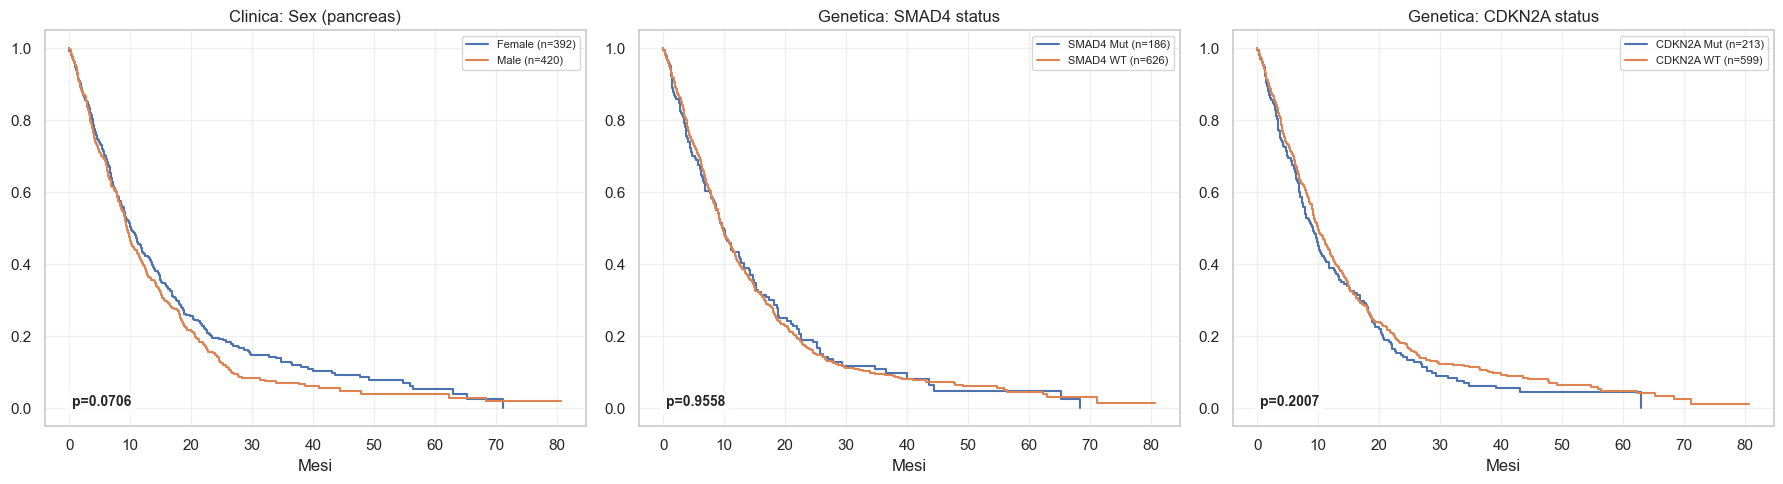

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

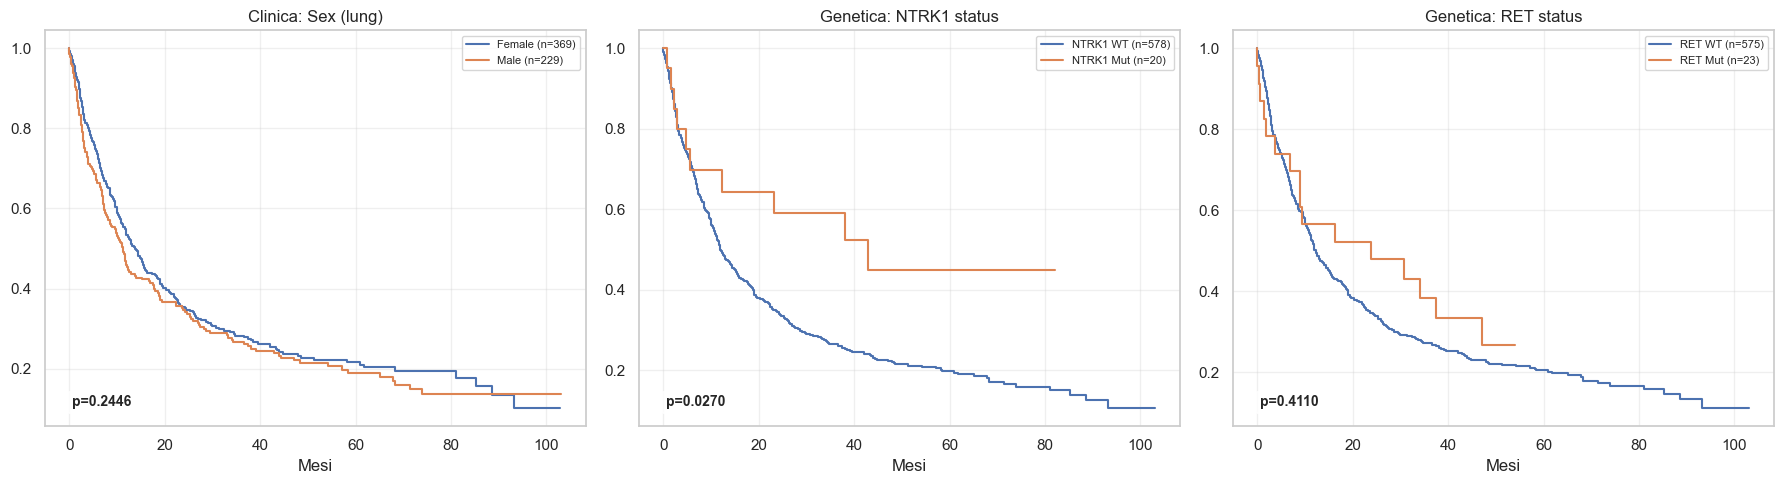

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

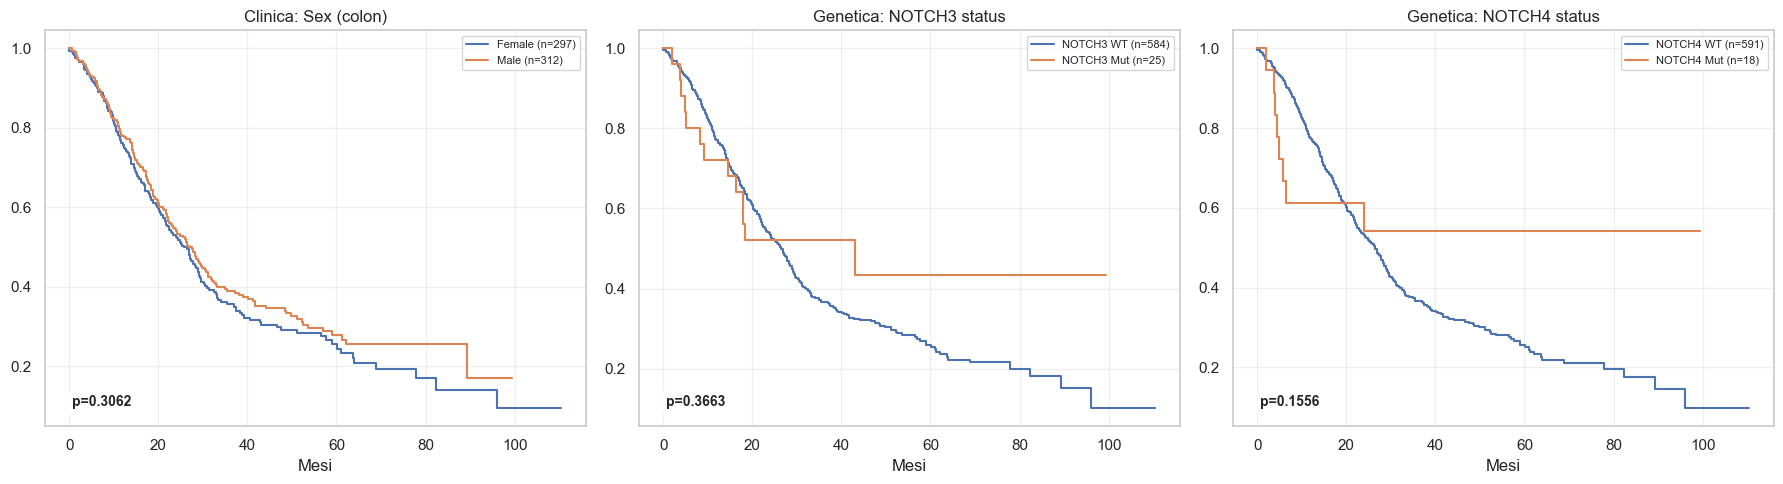

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

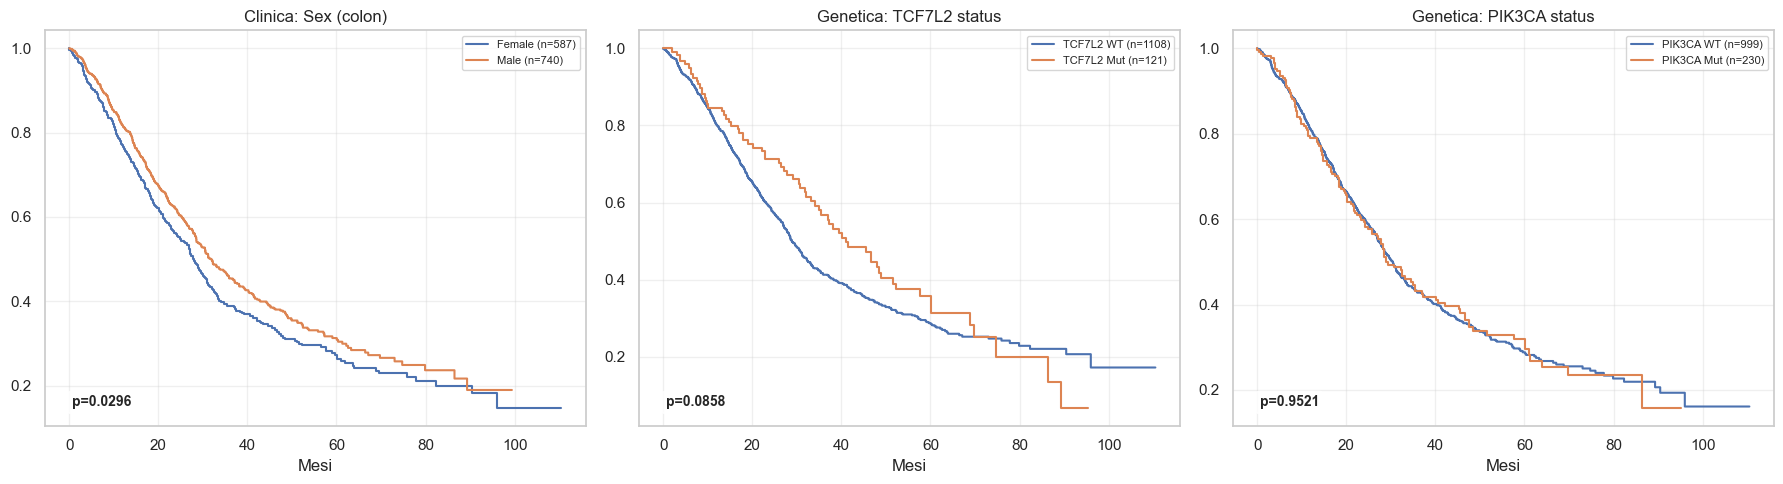

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

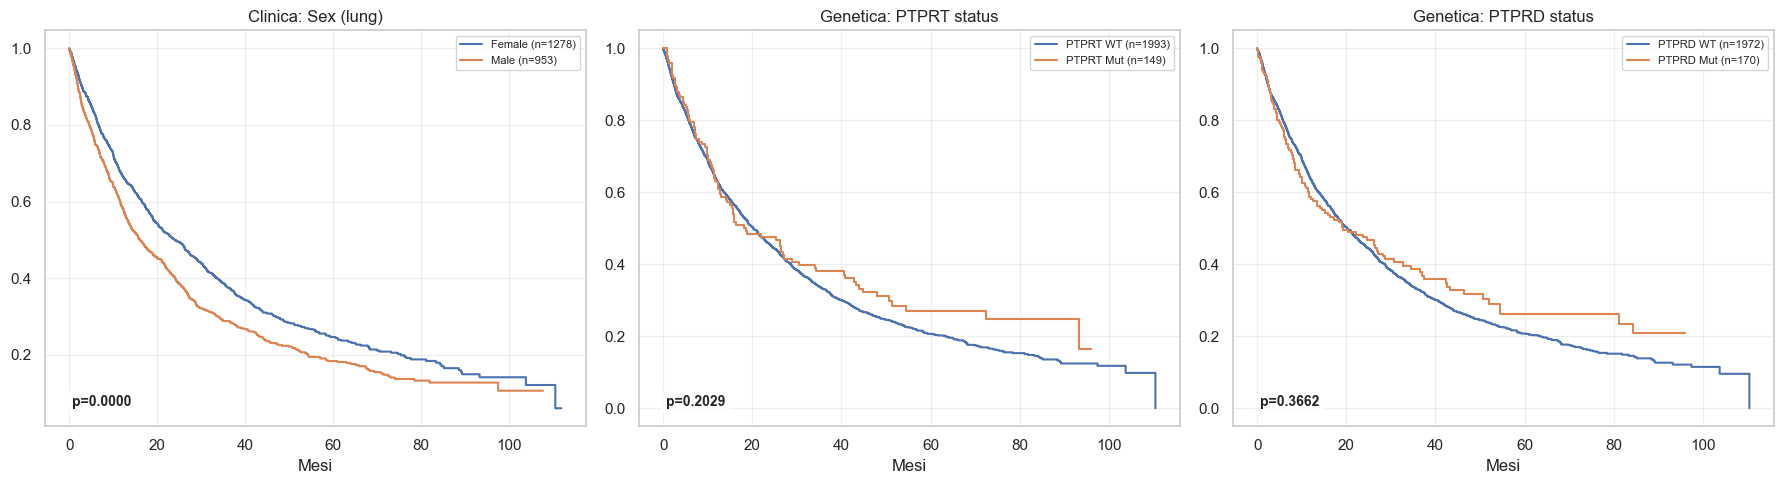

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

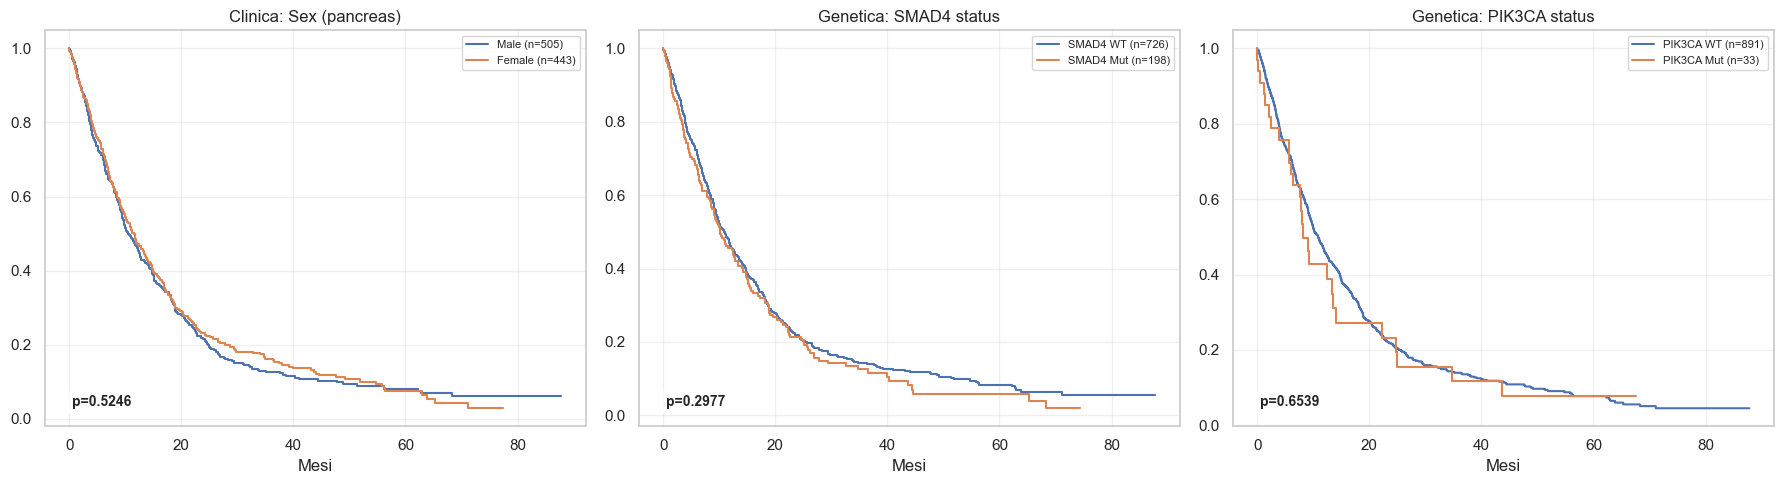

In [110]:

FEATURE_ANALIZZATA= 'Sex'


for coorte in COORTI:
    if "kras_" in coorte:
        coorte_base = coorte.replace("kras_", "")
        path_clinical = f"./data_filtered/{coorte}/KRAS_F_{coorte_base}.csv"
        path_enrich = f"./outputs_mut/{coorte}/intracluster/Hubs_Global_Enrichment_FULL_{coorte}.tsv"
    else:
        coorte_base = coorte
        path_clinical = f"./data_filtered/{coorte}/F_{coorte_base}.csv"
        path_enrich = f"./outputs_mut/{coorte}/intracluster/Hubs_Global_Enrichment_FULL_{coorte}.tsv"
    
    if os.path.exists(path_clinical):
        df_clinical = pd.read_csv(path_clinical, sep='\t')
        print (f"Ecco tutte le possibili colonne: {df_clinical.columns.tolist()}")
        df_mut = load_mutation_matrix(coorte)
        
        if df_mut is not None:
            # 1. Recupero geni dal file di Enrichment (primi 2 geni del top pathway)
            genes_to_test = []
            if os.path.exists(path_enrich):
                df_enrich = pd.read_csv(path_enrich, sep='\t')
                if not df_enrich.empty:
                    # Estraiamo i geni separati da ';' e prendiamo i primi due
                    genes_to_test = str(df_enrich.iloc[0]['Genes']).split(';')[:2]

            # 2. Creazione della riga di grafici (1 riga, 3 colonne)
            print(f"\n📊 GENERANDO ANALISI PER: {coorte.upper()}")
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            # --- Colonna 0: Clinica (Sesso) ---
            plot_kaplan_meier(df_clinical, group_col=FEATURE_ANALIZZATA, ax=axes[0])
            axes[0].set_title(f"Clinica: {FEATURE_ANALIZZATA} ({coorte_base})")
            
            # --- Colonne 1 e 2: Geni Hub ---
            for i in range(2):
                target_ax = axes[i+1]
                if i < len(genes_to_test):
                    gene = genes_to_test[i]
                    survival_by_gene_hub(df_clinical, df_mut, gene, ax=target_ax)
                    target_ax.set_title(f"Genetica: {gene} status")
                else:
                    target_ax.axis('off') # Nascondi se non ci sono geni

            plt.tight_layout()
            plt.show()

    else:
        print(f"[-] File clinico non trovato: {path_clinical}")

In [111]:
# =================================================================
# CELLA DIAGNOSTICA: VALIDAZIONE CLUSTER E P-VALUE (SOPRAVVIVENZA)
# =================================================================

def get_hubs_from_report_final(report_path):
    """Estrae i cluster e i relativi hub dal file di report .txt"""
    clusters = {}
    current_cluster = None
    if not os.path.exists(report_path):
        print(f"   [!] File report non trovato: {report_path}")
        return None
    
    with open(report_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            # Identifica il cluster (es: 🎯 CLUSTER 0)
            if '🎯 CLUSTER' in line:
                current_cluster = line.split('|')[0].replace('🎯', '').strip()
                clusters[current_cluster] = []
            # Identifica il gene Hub (es: 🔸 HUB: RNF43)
            elif '🔸 HUB:' in line and current_cluster:
                gene = line.split(':')[1].strip()
                clusters[current_cluster].append(gene)
    return clusters

print(f"🚀 Avvio scansione clinica sui Cluster di Leiden...")

for coorte in COORTI:
    if "kras_" in coorte:

        nome_tumore = coorte.replace("kras_", "")
        path_clinical = f"./data_filtered/{coorte}/KRAS_F_{nome_tumore}.csv"
        path_report = f"./outputs_mut/{coorte}/intracluster/Report_Prof_TopHubs_FULL_{coorte}.txt"
    else:
        nome_tumore = coorte
        path_clinical = f"./data_filtered/{coorte}/F_{nome_tumore}.csv"
        path_report = f"./outputs_mut/{coorte}/intracluster/Report_Prof_TopHubs_FULL_{coorte}.txt"
    
    if os.path.exists(path_clinical):
        df_clinical = pd.read_csv(path_clinical, sep='\t')
        df_mut = load_mutation_matrix(coorte)
        cluster_data = get_hubs_from_report_final(path_report)
        
        if df_mut is not None and cluster_data:
            print(f"\n" + "═"*60)
            print(f" 🧬 ANALISI SIGNIFICATIVITÀ: {coorte.upper()}")
            print("═"*60)

            for cluster_name, genes in cluster_data.items():
                # Filtriamo i geni presenti nella matrice
                valid_genes = [g for g in genes if g in df_mut.columns]
                
                if valid_genes:
                    df_c = df_clinical.copy()
                    df_c['Sample_Id'] = df_c['Sample_Id'].astype(str)
                    
                    # Colonne OS (Overall Survival)
                    time_col = 'Overall Survival (Months)'
                    status_col = 'Overall Survival Status'
                    
                    # Pulizia dati per il calcolo del p-value
                    df_c = df_c.dropna(subset=[time_col, status_col])
                    df_c['Time'] = pd.to_numeric(df_c[time_col], errors='coerce')
                    df_c['Event'] = df_c[status_col].apply(lambda x: 1 if '1:DECEASED' in str(x).upper() else 0)
                    df_c = df_c.dropna(subset=['Time'])

                    # Identificazione pazienti mutati nel cluster (almeno uno dei top hub)
                    mut_indices = df_mut[df_mut[valid_genes].sum(axis=1) > 0].index
                    
                    # Suddivisione gruppi
                    mask_mut = df_c['Sample_Id'].isin(mut_indices)
                    group_mut = df_c[mask_mut]
                    group_wt = df_c[~mask_mut]

                    if len(group_mut) > 1 and len(group_wt) > 1:
                        # Esecuzione Log-Rank Test (il p-value della Kaplan-Meier)
                        results = logrank_test(group_mut['Time'], group_wt['Time'], 
                                               event_observed_A=group_mut['Event'], 
                                               event_observed_B=group_wt['Event'])
                        
                        p_value = results.p_value
                        sig_status = "✅ SIGNIFICATIVO" if p_value < 0.05 else "❌ NON SIG."
                        
                        print(f" {sig_status} | {cluster_name}")
                        print(f"    - P-Value: {p_value:.6f}")
                        print(f"    - Hubs testati: {valid_genes}")
                        print(f"    - Pazienti: Mutati={len(group_mut)}, Wild-Type={len(group_wt)}")
                        
                        # I PLOT SONO COMMENTATI
                        # plt.figure()
                        # plot_kaplan_meier(df_c, group_col='Cluster_Group')
                        # plt.show()
                    else:
                        print(f" ⚠️ {cluster_name}: Gruppi troppo piccoli per statistica.")
                else:
                    print(f" ⚠️ {cluster_name}: Nessun Hub del report trovato in matrice.")
    else:
        print(f"❌ File clinico non trovato in {path_clinical}")

🚀 Avvio scansione clinica sui Cluster di Leiden...

════════════════════════════════════════════════════════════
 🧬 ANALISI SIGNIFICATIVITÀ: KRAS_PANCREAS
════════════════════════════════════════════════════════════
 ❌ NON SIG. | CLUSTER 0
    - P-Value: 0.170220
    - Hubs testati: ['ARID1A', 'KMT2D', 'BRCA2']
    - Pazienti: Mutati=112, Wild-Type=700
 ❌ NON SIG. | CLUSTER 1
    - P-Value: 0.838780
    - Hubs testati: ['SMAD4', 'PREX2', 'AKT3']
    - Pazienti: Mutati=197, Wild-Type=615
 ❌ NON SIG. | CLUSTER 2
    - P-Value: 0.970417
    - Hubs testati: ['RNF43', 'RBM10', 'BCOR']
    - Pazienti: Mutati=84, Wild-Type=728
 ❌ NON SIG. | CLUSTER 3
    - P-Value: 0.215820
    - Hubs testati: ['CDKN2A', 'ABL1', 'BAP1']
    - Pazienti: Mutati=214, Wild-Type=598
 ❌ NON SIG. | CLUSTER 5
    - P-Value: 0.159109
    - Hubs testati: ['ATM', 'EP300', 'DOT1L']
    - Pazienti: Mutati=54, Wild-Type=758

════════════════════════════════════════════════════════════
 🧬 ANALISI SIGNIFICATIVITÀ: KRAS_LUNG
